<a href="https://colab.research.google.com/github/mrsivanandareddy/text_summarization/blob/main/thesis_summarization_using_GenAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Thesis Summarization Notebook

## Overview

This notebook implements the summarization workflow used in the dissertation. It includes dataset loading, preprocessing, exploratory analysis, train/validation/test splitting, summary generation, and evaluation.

**Dataset:** BBC News RSS (`bbc_news.csv`) from Google Drive  
**Purpose:** To reproduce the summarization experiments in Google Colab.


## What this notebook produces (outputs generated by the notebook)
- **EDA tables + plots** (length distributions)
- **Train/Val/Test split** (70/15/15)
- Summaries: Extractive Lead-3, BART, T5 (optional GPT)
- **Evaluation tables**: ROUGE-1/2/L + Readability (FKGL, Flesch)
- **Outputs**: `summaries_test.csv`, `results_table.csv`, plots PNGs

> Note: BBC RSS dataset includes `title` and `description` (short summary). By default:
- **Input** = `description`  
- **Reference** = `title` (proxy reference)  
An optional scraping section is included for experiments using full article text as input.


## 0) Install dependencies (Colab)
Install the required dependencies in a new Colab session. Restart the runtime after installation if needed.

In [ ]:
!pip install --upgrade --force-reinstall numpy scikit-learn

In [ ]:
!pip -q install -U "transformers==4.46.3" "tokenizers==0.20.1" "accelerate>=0.34.0" "huggingface_hub>=0.24.0" "safetensors>=0.4.5"
!pip -q install -U evaluate rouge-score textstat matplotlib scikit-learn pandas numpy
!pip install wordcloud

import transformers, tokenizers
print("transformers:", transformers.__version__)
print("tokenizers:", tokenizers.__version__)
print("Installation complete. Restart the runtime session")


transformers: 4.46.3
tokenizers: 0.20.1
✅ Install complete. Recommended: Runtime → Restart runtime


## 1) Imports & reproducibility

In [ ]:
import os, re, time, random
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import textstat
import evaluate
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)
print("torch:", torch.__version__)


Using device: cpu
torch: 2.10.0+cpu


## 2) Load BBC News Dataset

The dataset is loaded from Google Drive using the specified file path.

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

CSV_PATH = '/content/drive/My Drive/content/Thesis/data/raw/bbc_news.csv'

if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f"CSV not found at: {CSV_PATH}\nUpdate CSV_PATH to your Drive file path.")

df = pd.read_csv(CSV_PATH)
print("Shape:", df.shape)
print("Columns:", list(df.columns))
df.head(2)


Mounted at /content/drive
Shape: (42115, 5)
Columns: ['title', 'pubDate', 'guid', 'link', 'description']


,title,pubDate,guid,link,description
0,Ukraine: Angry Zelensky vows to punish Russian...,"Mon, 07 Mar 2022 08:01:56 GMT",https://www.bbc.co.uk/news/world-europe-60638042,https://www.bbc.co.uk/news/world-europe-606380...,The Ukrainian president says the country will ...
1,War in Ukraine: Taking cover in a town under a...,"Sun, 06 Mar 2022 22:49:58 GMT",https://www.bbc.co.uk/news/world-europe-60641873,https://www.bbc.co.uk/news/world-europe-606418...,"Jeremy Bowen was on the frontline in Irpin, as..."


## 3) Column mapping + cleaning

In [ ]:
TITLE_COL = "title"
DESC_COL  = "description"
LINK_COL  = "link"      # optional
DATE_COL  = "pubDate"   # optional
GUID_COL  = "guid"      # optional

required = [TITLE_COL, DESC_COL]
missing = [c for c in required if c not in df.columns]
if missing:
    print("Missing columns:", missing)
    print("Available columns:", list(df.columns))
    raise ValueError("Update TITLE_COL/DESC_COL to match your CSV columns.")

def clean_text(t):
    if pd.isna(t):
        return ""
    t = str(t)
    t = re.sub(r"<[^>]+>", " ", t)      # strip HTML
    t = re.sub(r"\s+", " ", t).strip()
    return t

df[TITLE_COL] = df[TITLE_COL].apply(clean_text)
df[DESC_COL]  = df[DESC_COL].apply(clean_text)

# Filter invalid or incomplete rows
df = df[(df[TITLE_COL].str.len() > 5) & (df[DESC_COL].str.len() > 30)].copy().reset_index(drop=True)
print("After cleaning:", df.shape)

# Define input and reference columns for the RSS summarization task
INPUT_COL = DESC_COL   # summarize this
REF_COL   = TITLE_COL  # compare to this (proxy reference)

df[[TITLE_COL, DESC_COL]].head(3)


After cleaning: (42099, 5)


,title,description
0,Ukraine: Angry Zelensky vows to punish Russian...,The Ukrainian president says the country will ...
1,War in Ukraine: Taking cover in a town under a...,"Jeremy Bowen was on the frontline in Irpin, as..."
2,Ukraine war 'catastrophic for global food',One of the world's biggest fertiliser firms sa...


## 4) Exploratory Data Analysis

This section calculates basic length statistics and generates plots for input and reference summaries.

In [ ]:
def word_count(s: str) -> int:
    return len((s or "").split())

df["input_words"] = df[INPUT_COL].apply(word_count)
df["ref_words"]   = df[REF_COL].apply(word_count)

eda_table = pd.DataFrame({
    "field": ["input_words", "ref_words"],
    "count": [df["input_words"].count(), df["ref_words"].count()],
    "mean":  [df["input_words"].mean(),  df["ref_words"].mean()],
    "median":[df["input_words"].median(),df["ref_words"].median()],
    "p90":   [df["input_words"].quantile(0.9), df["ref_words"].quantile(0.9)],
    "max":   [df["input_words"].max(),   df["ref_words"].max()],
})
eda_table


,field,count,mean,median,p90,max
0,input_words,42099,17.557258,17.0,23.0,45
1,ref_words,42099,9.659683,9.0,13.0,25


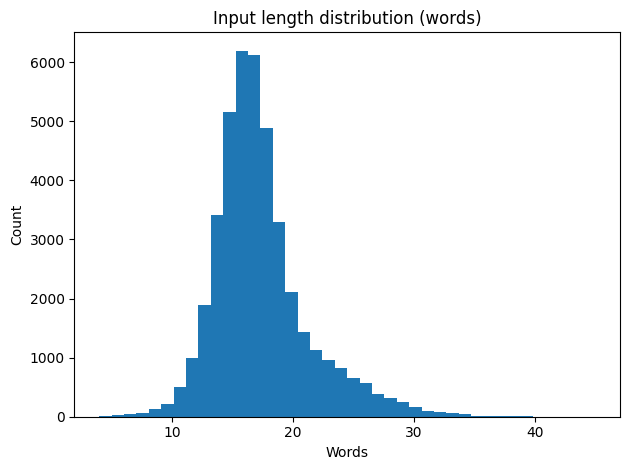

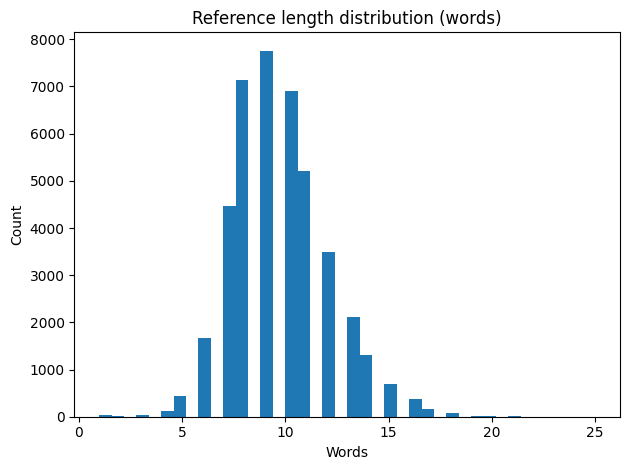

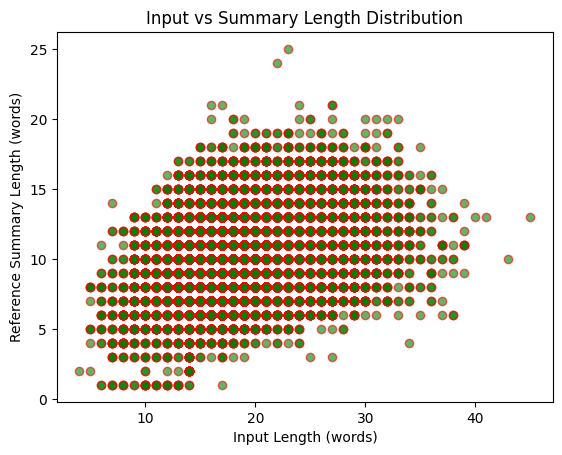

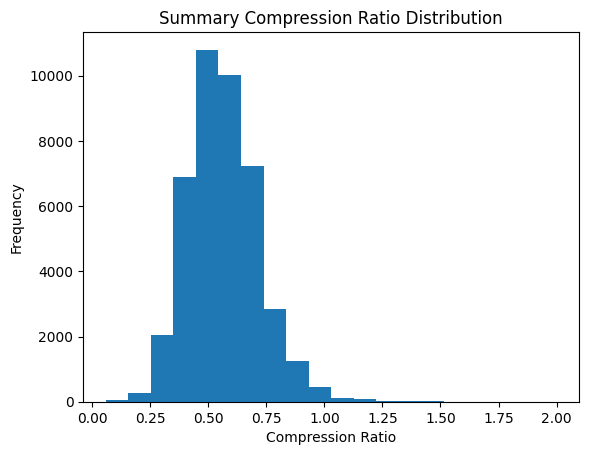

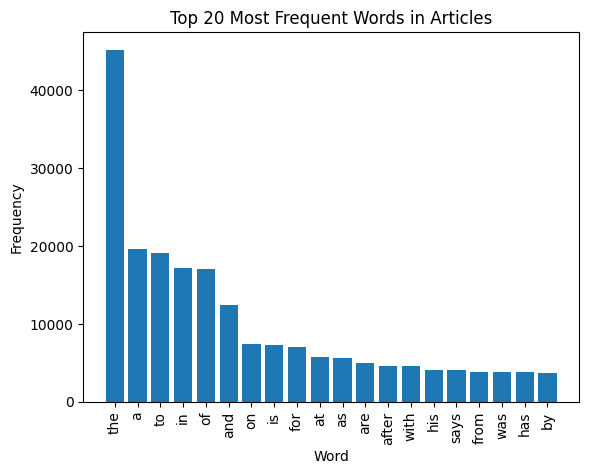

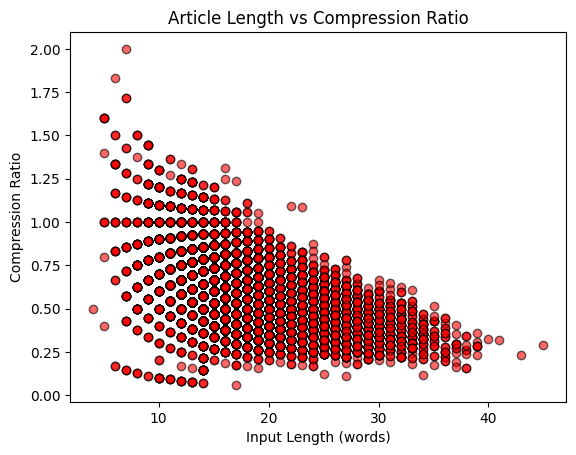

Saved plots: eda_input_words_hist.png, eda_ref_words_hist.png, eda_input_vs_summary_scatter.png, eda_compression_ratio.png, eda_top_words.png, eda_length_vs_compression.png


In [ ]:
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd

plt.figure()
plt.hist(df["input_words"], bins=40)
plt.title("Input length distribution (words)")
plt.xlabel("Words")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("eda_input_words_hist.png", dpi=200)
plt.show()

plt.figure()
plt.hist(df["ref_words"], bins=40)
plt.title("Reference length distribution (words)")
plt.xlabel("Words")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("eda_ref_words_hist.png", dpi=200)
plt.show()


plt.figure()
plt.scatter(df["input_words"], df["ref_words"],  color="green", alpha=0.6,edgecolors="red")

plt.xlabel("Input Length (words)")
plt.ylabel("Reference Summary Length (words)")
plt.title("Input vs Summary Length Distribution")

plt.savefig("eda_input_vs_summary_scatter.png", dpi=300)
plt.show()

df["compression_ratio"] = df["ref_words"] / df["input_words"]

plt.figure()
plt.hist(df["compression_ratio"], bins=20)

plt.xlabel("Compression Ratio")
plt.ylabel("Frequency")
plt.title("Summary Compression Ratio Distribution")


plt.savefig("eda_compression_ratio.png", dpi=300)
plt.show()

words = " ".join(df[INPUT_COL].astype(str)).lower().split()
common_words = Counter(words).most_common(20)

df_common = pd.DataFrame(common_words, columns=["word", "count"])

plt.figure()
plt.bar(df_common["word"], df_common["count"])

plt.xticks(rotation=90)
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.title("Top 20 Most Frequent Words in Articles")

plt.savefig("eda_top_words.png", dpi=300)
plt.show()

plt.figure()
plt.scatter(df["input_words"],df["compression_ratio"],  color="red", alpha=0.6,edgecolors="black")

plt.xlabel("Input Length (words)")
plt.ylabel("Compression Ratio")
plt.title("Article Length vs Compression Ratio")

plt.savefig("eda_length_vs_compression.png", dpi=300)
plt.show()

print("Saved plots: eda_input_words_hist.png, eda_ref_words_hist.png, eda_input_vs_summary_scatter.png, eda_compression_ratio.png, eda_top_words.png, eda_length_vs_compression.png")




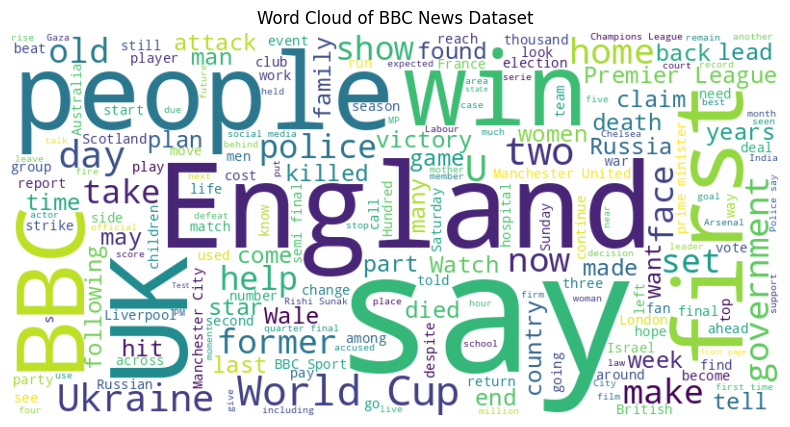

In [ ]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Combine article text for frequency analysis
text = " ".join(df[INPUT_COL].astype(str))

custom_stopwords = set(STOPWORDS)
custom_stopwords.update(["said","will","one","also","new","year"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    stopwords=custom_stopwords,
    colormap="viridis"
).generate(text)

# Generate plot
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of BBC News Dataset")

# Save output figures
plt.savefig("eda_wordcloud.png", dpi=300)

plt.show()

## 5) Train, Validation, and Test Split
Uses fixed random seed for reproducibility.

In [ ]:
train_df, temp_df = train_test_split(df, test_size=0.30, random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=SEED)

print("train:", train_df.shape, "val:", val_df.shape, "test:", test_df.shape)

# Save splits
train_df.to_csv("train_split.csv", index=False)
val_df.to_csv("val_split.csv", index=False)
test_df.to_csv("test_split.csv", index=False)

print("Saved: train_split.csv, val_split.csv, test_split.csv")


train: (29469, 7) val: (6315, 7) test: (6315, 7)
Saved: train_split.csv, val_split.csv, test_split.csv


## 6) Subset Selection for Evaluation

In [ ]:
work_df = test_df.sample(min(SAMPLE_N, len(test_df)), random_state=SEED).copy().reset_index(drop=True)
print("work_df:", work_df.shape)


work_df: (200, 7)


## 7) Extractive Baseline: Lead-3
The Lead-3 baseline is implemented using regular-expression sentence splitting.

In [ ]:
# Sentence splitting using regular expressions
_SENT_SPLIT = re.compile(r'(?<=[.!?])\s+')

def lead3(text: str, max_sent: int = 3) -> str:
    text = (text or "").strip()
    if not text:
        return ""
    sents = _SENT_SPLIT.split(text)
    return " ".join(sents[:max_sent]).strip()

work_df["summary_extractive"] = work_df[INPUT_COL].apply(lead3)
work_df[["summary_extractive"]].head(2)


,summary_extractive
0,Watch the best moments from day three of The H...
1,"All of England's players are ""ready for when t..."


## 8) Load BART and T5 Models

In [ ]:
# --- BART ---
bart_id = "facebook/bart-large-cnn"
bart_tok = AutoTokenizer.from_pretrained(bart_id)
bart_model = AutoModelForSeq2SeqLM.from_pretrained(bart_id).to(DEVICE)

# Set decoder start token if required by the model configuration
if getattr(bart_model.config, "forced_bos_token_id", None) is None:
    bart_model.config.forced_bos_token_id = 0

def bart_summarize(text, max_len=120, min_len=30):
    text = (text or "")[:4000]
    inputs = bart_tok(text, return_tensors="pt", truncation=True, max_length=1024).to(DEVICE)
    ids = bart_model.generate(
        **inputs,
        max_length=max_len,
        min_length=min_len,
        num_beams=4,
        length_penalty=2.0,
        early_stopping=True,
        no_repeat_ngram_size=3,
    )
    return bart_tok.decode(ids[0], skip_special_tokens=True)

# --- T5 ---
t5_id = "t5-base"
t5_tok = AutoTokenizer.from_pretrained(t5_id)
t5_model = AutoModelForSeq2SeqLM.from_pretrained(t5_id).to(DEVICE)

def t5_summarize(text, max_len=120, min_len=30):
    text = (text or "")[:3500]
    prefixed = "summarize: " + text
    inputs = t5_tok(prefixed, return_tensors="pt", truncation=True, max_length=512).to(DEVICE)
    ids = t5_model.generate(
        **inputs,
        max_length=max_len,
        min_length=min_len,
        num_beams=4,
        length_penalty=2.0,
        early_stopping=True,
        no_repeat_ngram_size=3,
    )
    return t5_tok.decode(ids[0], skip_special_tokens=True)

print("BART and T5 Models loaded.")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

✅ Models loaded.


## 9) Summary Generation and Runtime Measurement

In [ ]:
# Optional: use a smaller subset for trial execution
# work_df = work_df.head(30).copy()

t0 = time.time()
work_df["summary_bart"] = work_df[INPUT_COL].apply(bart_summarize)
t_bart = time.time() - t0



print(f"BART time (s): {t_bart:.1f} for {len(work_df)} samples")




BART time (s): 1708.8 for 200 samples


In [ ]:
t0 = time.time()
work_df["summary_t5"] = work_df[INPUT_COL].apply(t5_summarize)
t_t5 = time.time() - t0
print(f"T5 time (s):   {t_t5:.1f} for {len(work_df)} samples")

T5 time (s):   1162.9 for 200 samples


In [ ]:
work_df[[INPUT_COL, "summary_extractive", "summary_bart", "summary_t5"]].head(3)

,description,summary_extractive,summary_bart,summary_t5
0,Watch the best moments from day three of The H...,Watch the best moments from day three of The H...,Watch the best moments from day three of The H...,watch the best moments from day three of The H...
1,"All of England's players are ""ready for when t...","All of England's players are ""ready for when t...","All of England's players are ""ready for when t...","all of England's players are ""ready for when t..."
2,Transgender people can be excluded from some s...,Transgender people can be excluded from some s...,Transgender people can be excluded from some s...,transgender people can be excluded from some s...


## 10) Evaluation: ROUGE + Readability (FKGL, Flesch)

In [ ]:
rouge = evaluate.load("rouge")

def rouge_scores(preds, refs):
    return rouge.compute(predictions=preds, references=refs, use_stemmer=True)

def readability(text: str):
    if not isinstance(text, str) or len(text.strip()) < 5:
        return {"fkgl": np.nan, "flesch": np.nan}
    return {
        "fkgl": textstat.flesch_kincaid_grade(text),
        "flesch": textstat.flesch_reading_ease(text),
    }

def eval_model(pred_col):
    preds = work_df[pred_col].fillna("").tolist()
    refs  = work_df[REF_COL].fillna("").tolist()
    r = rouge_scores(preds, refs)
    read = work_df[pred_col].apply(readability).apply(pd.Series).mean(numeric_only=True).to_dict()
    return {**r, **read}

model_cols = ["summary_extractive", "summary_bart", "summary_t5"]
results = [{"model": m, **eval_model(m)} for m in model_cols]
results_df = pd.DataFrame(results).sort_values("rougeL", ascending=False)
results_df


,model,rouge1,rouge2,rougeL,rougeLsum,fkgl,flesch
0,summary_extractive,0.218518,0.066552,0.17596,0.176058,9.603652,56.336660
2,summary_t5,0.182387,0.057644,0.14689,0.146931,7.302135,64.930020
1,summary_bart,0.176222,0.054799,0.14317,0.142994,7.653290,65.115236


## 11) Save Output Files

Saved: summaries_test.csv, results_table.csv, eda_table.csv


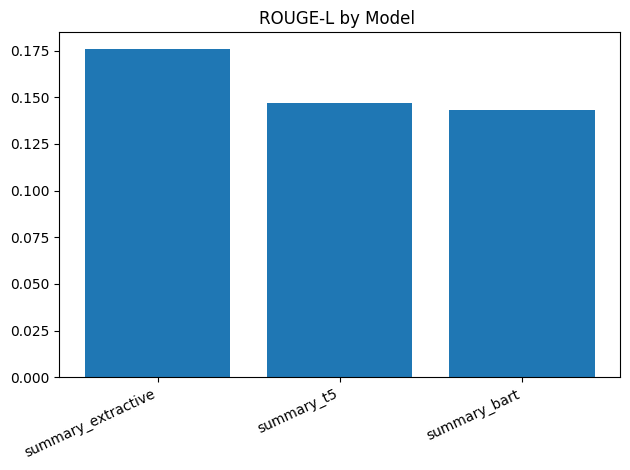

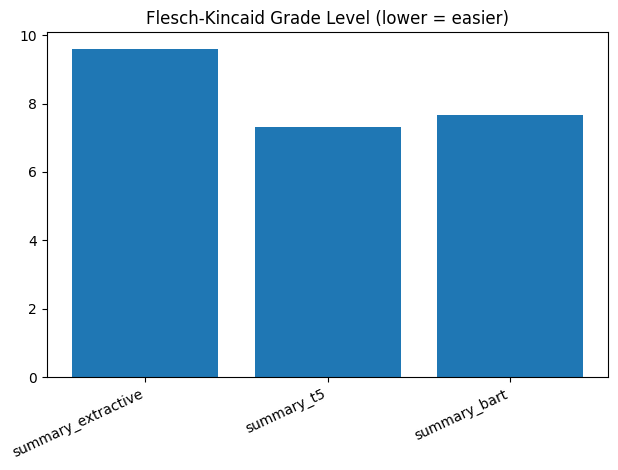

Saved plots: rougeL_by_model.png, fkgl_by_model.png


In [ ]:
# Save outputs
work_df.to_csv("summaries_test.csv", index=False)
results_df.to_csv("results_table.csv", index=False)
eda_table.to_csv("eda_table.csv", index=False)

print("Saved: summaries_test.csv, results_table.csv, eda_table.csv")

# Plot ROUGE-L
plt.figure()
plt.bar(results_df["model"], results_df["rougeL"])
plt.xticks(rotation=25, ha="right")
plt.title("ROUGE-L by Model ")
plt.tight_layout()
plt.savefig("rougeL_by_model.png", dpi=200)
plt.show()

# Plot FKGL
plt.figure()
plt.bar(results_df["model"], results_df["fkgl"])
plt.xticks(rotation=25, ha="right")
plt.title("Flesch-Kincaid Grade Level (lower = easier)")
plt.tight_layout()
plt.savefig("fkgl_by_model.png", dpi=200)
plt.show()

print("Saved plots: rougeL_by_model.png, fkgl_by_model.png")


## 12) Qualitative Examples for Error Analysis


In [ ]:
cols = [REF_COL, INPUT_COL, "summary_extractive", "summary_bart", "summary_t5"]
work_df[cols].head(5)


,title,description,summary_extractive,summary_bart,summary_t5
0,The Hundred 2023: Ben Duckett's six and Georgi...,Watch the best moments from day three of The H...,Watch the best moments from day three of The H...,Watch the best moments from day three of The H...,watch the best moments from day three of The H...
1,England v Chile: Jack Willis 'prepared and rea...,"All of England's players are ""ready for when t...","All of England's players are ""ready for when t...","All of England's players are ""ready for when t...","all of England's players are ""ready for when t..."
2,Human rights watchdog publishes single-sex spa...,Transgender people can be excluded from some s...,Transgender people can be excluded from some s...,Transgender people can be excluded from some s...,transgender people can be excluded from some s...
3,Sunak accuses Labour of asking for a blank cheque,Keir Starmer says his manifesto is aimed at we...,Keir Starmer says his manifesto is aimed at we...,Keir Starmer says his manifesto is aimed at we...,Keir Starmer says his manifesto is aimed at we...
4,Euro 2022: Lionesses' success shows how far ga...,Footage of a jubilant fan enjoying England's v...,Footage of a jubilant fan enjoying England's v...,Footage of a jubilant fan enjoying England's v...,footage of a jubilant fan enjoying England's v...


## 13) GPT-Based Summarization
This section is used to generate GPT summaries through API access.

In [ ]:
filepath = '/content/drive/My Drive/content/Thesis/'
# Load OpenAI API key from environment
with open(filepath + "OPENAI_API_Key.txt","r") as f:
  OPENAI_API_KEY  = ' '.join(f.readlines())

  os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY

In [ ]:
from time import sleep
from openai import OpenAI
client = OpenAI()

def gpt_summarize(text: str) -> str:
    text = (text or "")[:8000]
    prompt = (
        "Summarize the following news text into 4-6 bullet points. "
        "Be factual and do not add information not present in the text.\n\n"
        f"TEXT:\n{text}"
    )
    resp = client.chat.completions.create(
        model="gpt-4.1-mini",
        messages=[{"role":"user","content": prompt}],
        temperature=0.2
    )
    return resp.choices[0].message.content.strip()

# work_df["summary_gpt"] = work_df[INPUT_COL].apply(gpt_summarize)

def gpt_summarize_safe(text):
    try:
        return gpt_summarize(text)
    except Exception as e:
        return "ERROR"

# work_df["summary_gpt"] = []

for i, text in enumerate(work_df[INPUT_COL]):
    summary = gpt_summarize_safe(text)
    work_df.loc[i, "summary_gpt"] = summary
    sleep(1)


In [ ]:
candidate_cols = ["summary_extractive", "summary_bart", "summary_t5", "summary_gpt"]
model_cols = [c for c in candidate_cols if c in work_df.columns]

print("Evaluating models:", model_cols)

results = [{"model": m, **eval_model(m)} for m in model_cols]
results_df = pd.DataFrame(results).sort_values("rougeL", ascending=False)

work_df.to_csv("summaries_test.csv", index=False)
results_df.to_csv("results_table.csv", index=False)

results_df

Evaluating models: ['summary_extractive', 'summary_bart', 'summary_t5', 'summary_gpt']


,model,rouge1,rouge2,rougeL,rougeLsum,fkgl,flesch
0,summary_extractive,0.218518,0.066552,0.175960,0.176058,9.603652,56.336660
2,summary_t5,0.182387,0.057644,0.146890,0.146931,7.302135,64.930020
1,summary_bart,0.176222,0.054799,0.143170,0.142994,7.653290,65.115236
3,summary_gpt,0.153015,0.037944,0.127743,0.137975,8.066210,54.546094


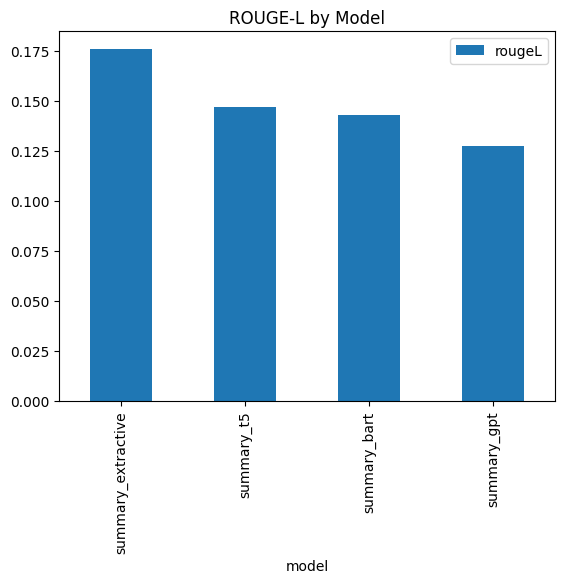

In [ ]:
results_df.plot(x="model", y="rougeL", kind="bar")
plt.title("ROUGE-L by Model")
plt.savefig("rougeL_by_model.png")
plt.show()

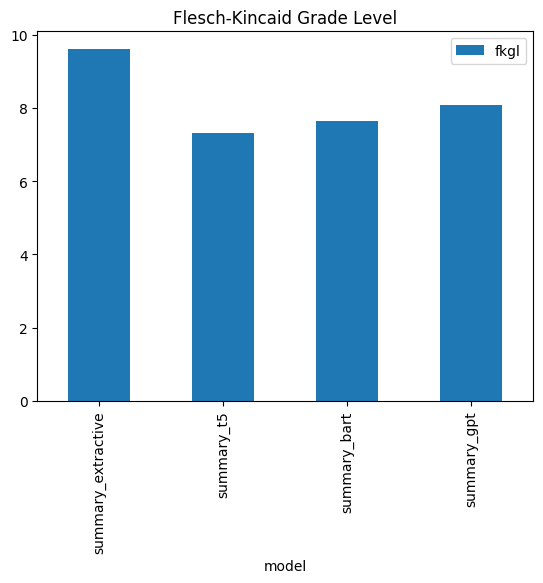

In [ ]:
results_df.plot(x="model", y="fkgl", kind="bar")
plt.title("Flesch-Kincaid Grade Level")
plt.savefig("fkgl_by_model.png")
plt.show()

## 14) Full-Article Scraping
This section is used to extract full article text from source links for extended experiments

In [ ]:

!pip -q install requests beautifulsoup4 lxml
import requests
from bs4 import BeautifulSoup

def scrape_article(url: str, timeout=15) -> str:
    try:
        r = requests.get(url, timeout=timeout, headers={"User-Agent":"Mozilla/5.0"})
        if r.status_code != 200:
            return ""
        soup = BeautifulSoup(r.text, "lxml")
        paras = [p.get_text(" ", strip=True) for p in soup.find_all("p")]
        text = " ".join([p for p in paras if p and len(p) > 20])
        return clean_text(text)
    except Exception:
        return ""

SCRAPE_N = 200
scrape_df = df.sample(min(SCRAPE_N, len(df)), random_state=SEED).copy().reset_index(drop=True)
scrape_df["article_text"] = scrape_df[LINK_COL].apply(scrape_article)
scrape_df = scrape_df[scrape_df["article_text"].str.len() > 500].copy().reset_index(drop=True)

INPUT_COL = "article_text"
REF_COL   = DESC_COL
work_df = scrape_df.sample(min(SAMPLE_N, len(scrape_df)), random_state=SEED).copy().reset_index(drop=True)
print("Scraped usable articles:", work_df.shape)



Scraped usable articles: (197, 8)


## 15) Download Output Files

In [ ]:
from google.colab import files
for f in [
    "eda_table.csv",
    "train_split.csv", "val_split.csv", "test_split.csv",
    "summaries_test.csv", "results_table.csv",
    "eda_input_words_hist.png", "eda_ref_words_hist.png",
    "rougeL_by_model.png", "fkgl_by_model.png"
]:
    if os.path.exists(f):
        files.download(f)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>